### **ICESat数据查看**

In [3]:
import h5py
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
from pyrsimg import readTiff, imgShow


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [4]:
path_atl06 = 'data/icesat2/ATL06_20190821180402_08350402_006_02.h5'
path_rsimg = 'data/rsimg/setp_glacier_20200510_wgs84.tif'


In [54]:
!h5ls $path_atl06/gt1l
# !h5ls $path_atl06/gt1l/land_ice_segments
# !h5ls $path_atl06/orbit_info


land_ice_segments        Group
residual_histogram       Group
segment_quality          Group


In [56]:
with h5py.File(path_atl06,'r') as setp_atl06:
    ## gt1l
    lat_gt1l = setp_atl06['gt1l/land_ice_segments/latitude'][:]
    lon_gt1l = setp_atl06['gt1l/land_ice_segments/longitude'][:]
    elev_gt1l = setp_atl06['gt1l/land_ice_segments/h_li'][:]
    ## group attributes
    beam_type_gt1l = setp_atl06['gt1l'].attrs["atlas_beam_type"].decode()
    ## gt1r
    lat_gt1r = setp_atl06['gt1r/land_ice_segments/latitude'][:]
    lon_gt1r = setp_atl06['gt1r/land_ice_segments/longitude'][:]
    elev_gt1r = setp_atl06['gt1r/land_ice_segments/h_li'][:]
    beam_type_gt1r = setp_atl06['gt1r'].attrs["atlas_beam_type"].decode()
    ## gt3r
    lat_gt3r = setp_atl06['gt3r/land_ice_segments/latitude'][:]
    lon_gt3r = setp_atl06['gt3r/land_ice_segments/longitude'][:]
    elev_gt3r = setp_atl06['gt3r/land_ice_segments/h_li'][:]
    ## orbit information.
    cycle = setp_atl06['orbit_info/cycle_number'][0]
    track = setp_atl06['orbit_info/rgt'][0]
    orient = setp_atl06['orbit_info/sc_orient'][0]

## 2. remote sensing image
rsimg = readTiff(path_rsimg)



Text(0.5, 1.0, 'jason-3')

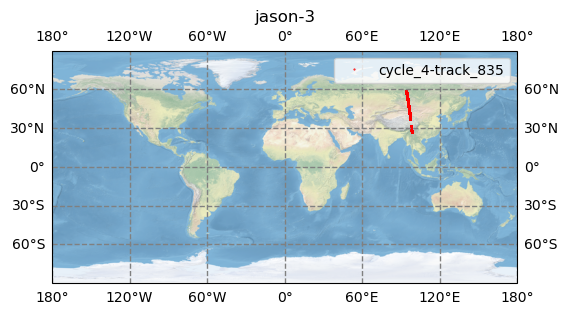

In [57]:
proj = ccrs.PlateCarree(central_longitude=0.0)
fig = plt.figure(figsize=(6, 6))
orbit_isat = 'cycle_'+str(cycle)+'-track_'+str(track)
ax3 = fig.add_subplot(111, projection=proj); 
ax3.stock_img()
ax3.plot(lon_gt1l, lat_gt1l, marker='.', markersize=1, linewidth=0.0, label=orbit_isat, color='red')
ax3.gridlines(draw_labels=True, linewidth=1, color='gray', linestyle='--')
ax3.legend(); 
plt.title('jason-3')


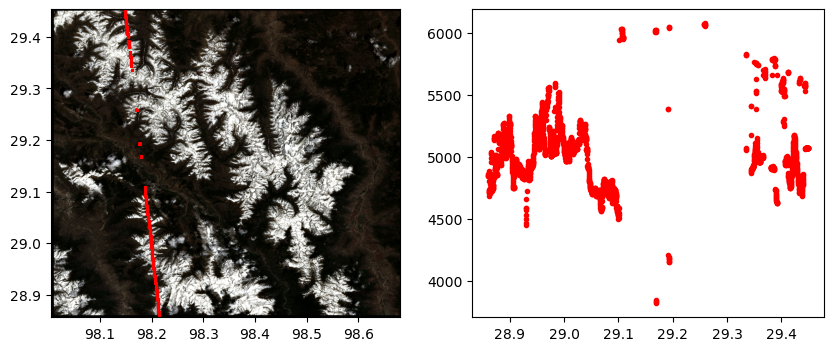

In [58]:
### gt1l
ids = np.where((lat_gt1l>28.86) & (lat_gt1l<29.45) & \
               (lon_gt1l>98) & (lon_gt1l<98.69) & (elev_gt1l<9000))
fig, ax = plt.subplots(1,2, figsize=(10, 4))
imgShow(rsimg.array, extent=rsimg.geoextent, clip_percent=5, ax=ax[0])
ax[0].scatter(x=lon_gt1l[ids], y=lat_gt1l[ids], s=1.5, color='red')  
ax[1].plot(lat_gt1l[ids], elev_gt1l[ids], 'r.')


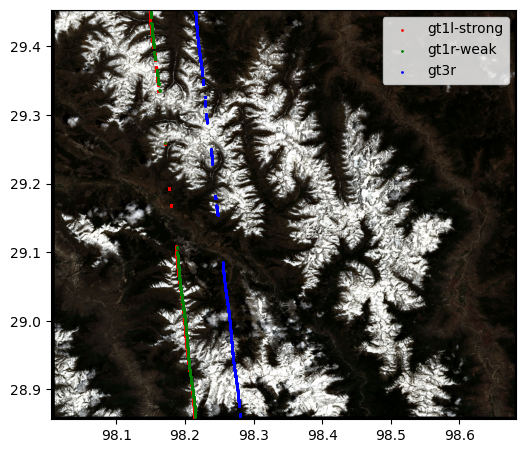

In [64]:
### gt1l vs. gt1r, gt3r
ids_gt1l = np.where((lat_gt1l>28.86) & (lat_gt1l<29.45) & \
                  (lon_gt1l>98) & (lon_gt1l<98.69) & (elev_gt1l<9000))[0]
ids_gt1r = np.where((lat_gt1r>28.86) & (lat_gt1r<29.45) & \
                  (lon_gt1r>98) & (lon_gt1r<98.69) & (elev_gt1r<9000))[0]
ids_gt3r = np.where((lat_gt3r>28.86) & (lat_gt3r<29.45) & \
                  (lon_gt3r>98) & (lon_gt3r<98.69) & (elev_gt3r<9000))[0]
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
imgShow(rsimg.array, extent=rsimg.geoextent, clip_percent=5, ax=ax)
ax.scatter(x=lon_gt1l[ids_gt1l], y=lat_gt1l[ids_gt1l], s=1, color='red', label='gt1l-'+beam_type_gt1l)  
ax.scatter(x=lon_gt1r[ids_gt1r], y=lat_gt1r[ids_gt1r], s=1, color='green', label='gt1r-'+beam_type_gt1r)  
ax.scatter(x=lon_gt3r[ids_gt3r], y=lat_gt3r[ids_gt3r], s=1, color='blue', label='gt3r')  
ax.legend()
